In [ ]:
#Exercise 4
#Task 1
#Create a 5 x 5 matrix

#importing numpy
import numpy as np

#creating matrix filled with interior 0s and border 1s
matrix = np.ones((5,5))

#Using slicing to make the interior elements zero
matrix[1:4, 1:4] =0

#Displaying the matrix
print(matrix)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [ ]:
# Task 2
#Normalizing a Random Array

#This sets the random number generator's starting point to 42
np.random.seed(42)

#This generates a 100 rows of random data with 3 values in each row
random_data = np.random.randn(100,3)

#Normalizing each column
normalized_data = (
    random_data - random_data.mean(axis=0)
) / random_data.std(axis=0)

#Checking the result
print("Means:")
print(normalized_data.mean(axis=0))

print("\nStandard Deviations:")
print(normalized_data.std(axis=0))

Means:
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]

Standard Deviations:
[1. 1. 1.]


In [ ]:
#Task 3 -Linear Regression Using the Normal Equation

#This creates a matrix with 50 rows and 3 columns containing random numbers
X = np.random.randn(50,3)

#This creates an array of three values that represent the true parameterss
true_theta = np.array([2.5, -1.2, 3.7])

#This calculates target values by multiplying the data matrix by the true parameters
#adding a small amount of noise
y = X @ true_theta + np.random.randn(50) * 0.1

#Computing each part of the equation
XT = X.T
theta_hat = np.linalg.inv(XT @ X) @ XT @ y

#Displaying the estimated coefficient
print("Estimated coeffiecients:")
print(theta_hat)

#Displaying the true coefficient
print("\nTrue coeffiecients:")
print(true_theta)

#Displaying the difference
print("\nDifference:")
print(theta_hat - true_theta)

Estimated coeffiecients:
[ 2.51723721 -1.19783796  3.72399266]

True coeffiecients:
[ 2.5 -1.2  3.7]

Difference:
[0.01723721 0.00216204 0.02399266]


In [ ]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Creating a  sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [ ]:
#Exercise 5
#Task 1: Data Cleaning and Exploration
#Displaying  basic information about the dataset
print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

#This identifies and count missing values
print("\nMissing Values:")
print(df.isnull().sum())

#Fills missing exam_score with the mean score for the student's major
df['exam_score']=df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)
#Fills missing hours_studied with the median for the student's year
df['hours_studied']= df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

#Verifying that the missing values are gone
print("\nMissing Values After Cleaning")
print(df.isnull().sum())

Dataset Shape:
(200, 6)

First 5 Rows:
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics     4   93.657745                      6      15.287370

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64

In [ ]:
#Task 2: Analysis

#Calculate and display the average exam_score by major
avg_scores = df.groupby('major')['exam_score'].mean()
print("Average Exam Score by Mayor:")
print(avg_scores)

#Find the major with the highest average exam_score
best_major = avg_scores.idxmax()

print("\nMajor with Highest Average Score:")
print(best_major)

#Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])

print("\nCorrelation:")
print(correlation)

#Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)

def performance_category(score):
    if score > 90:
        return "Excellent"
    elif score >= 80:
        return "Good"
    elif score >= 70:
        return "Average"
    else:
        return "Needs Improvement"

df['performance'] = df['exam_score'].apply(performance_category)
print(df[['exam_score','performance']].head())

Average Exam Score by Mayor:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Major with Highest Average Score:
CS

Correlation:
-0.05598138347292439
   exam_score        performance
0   68.199753  Needs Improvement
1   77.322537            Average
2   77.930725            Average
3   67.856486  Needs Improvement
4   93.657745          Excellent


In [ ]:
# Task 3: Advanced Analysis

#For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied

summary = df.groupby(['major','year']).agg({
    'student_id' : 'count',
    'exam_score' : 'mean',
    'hours_studied' : 'mean',
})

print(summary)

#Identify top 5 students based on exam_score
top_students = df.sort_values(
    'exam_score',
    ascending=False
).head(5)

print(top_students)

#Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print(pivot)

              student_id  exam_score  hours_studied
major   year                                       
Biology 1             13   76.570059      12.677806
        2             12   74.899613      13.426372
        3             14   80.178476      14.486815
        4             15   70.697689      14.253944
CS      1             12   77.098194      13.039480
        2              7   76.155936      13.995784
        3              9   72.347626      15.039892
        4             18   78.119997      16.275541
Math    1             11   74.053167      19.001215
        2              9   81.226714      12.345468
        3             10   72.017537      15.175871
        4             16   73.103066      17.419175
Physics 1             13   77.828686      13.489911
        2             12   73.277734      14.616778
        3             17   73.134319      14.199901
        4             12   78.130194      15.550491
     student_id    major  year  exam_score  assignments_complete

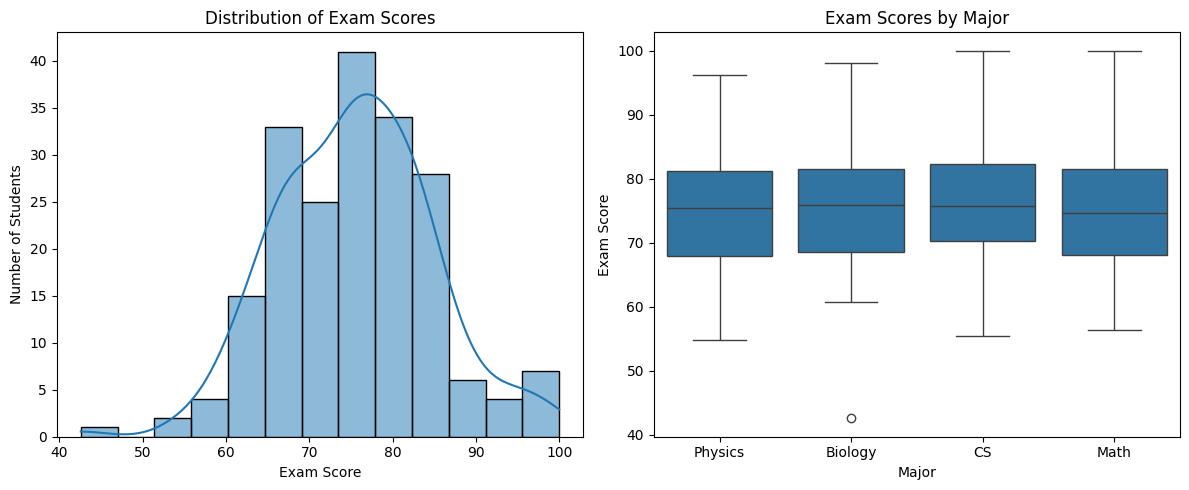

In [ ]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

#Task 1: Distribution Visualization
#Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
#Add appropriate titles, labels, and styling

# Creating figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Histogram with KDE
sns.histplot(
    data=df,
    x='exam_score',
    kde=True,
    ax=axes[0]
)

#Adding appropriate titles and labels
axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Number of Students')

#Creating a boxplot by major
sns.boxplot(
    data = df,
    x='major',
    y='exam_score',
    ax=axes[1]
)

axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

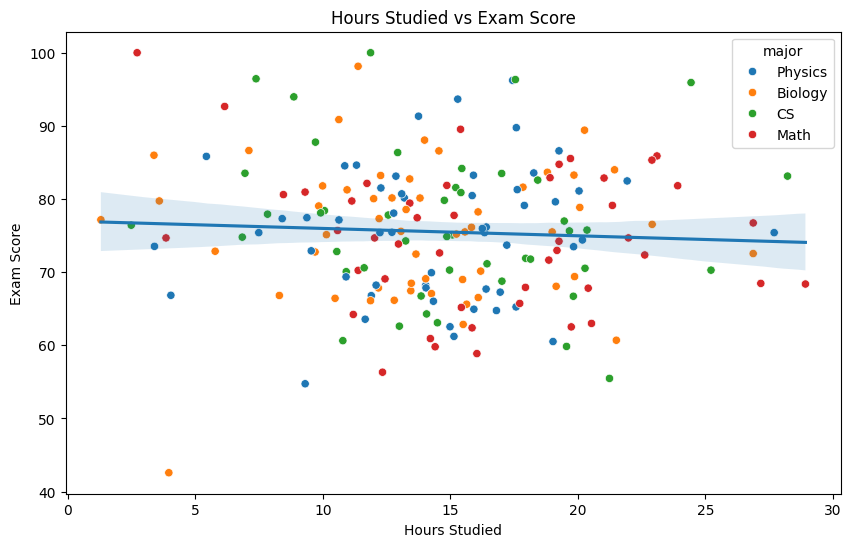

In [ ]:
# Task 2: Relationship Visualization (8 points)
#Create a scatter plot of hours_studied vs exam_score
#Color points by major
#Add a regression line
#Include appropriate legends, titles, and axis labels


#This creates a new figure with a size of 10 inches wide and 6 inches tall.
plt.figure(figsize=(10, 6))


#Creates the scatter plot showing the relationship between hours
#studied and exam score, with points colored differently based on
#each student's major
sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)

#This adds a regression line
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False
)


#This gives the title,and labels the x and y axis
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')


#This shows the scatter plot
plt.show()

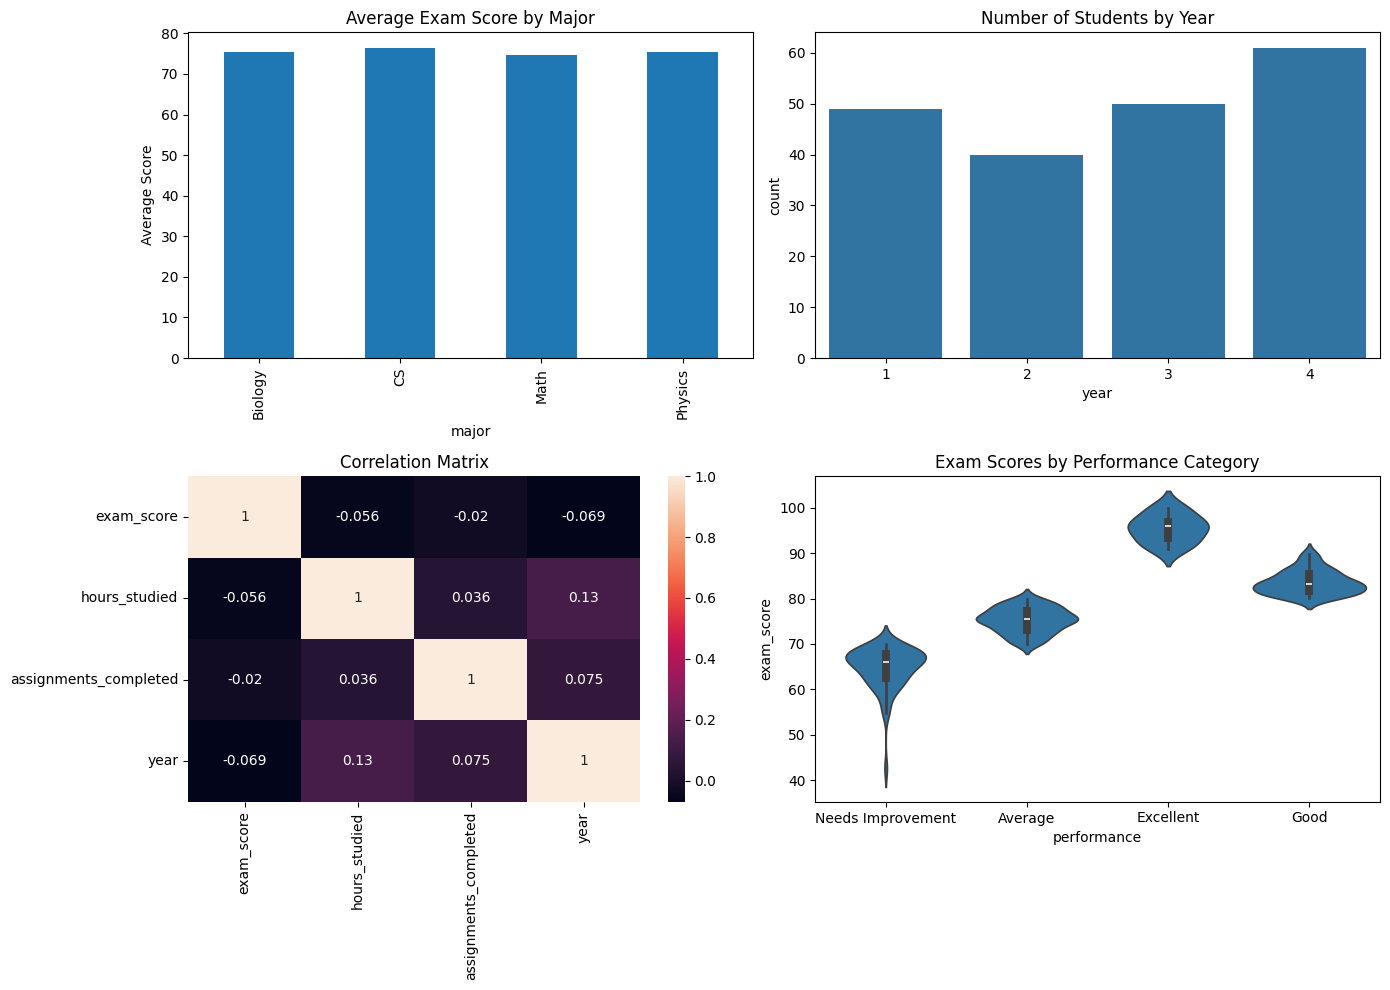

In [ ]:
#Task 3: Advanced Dashboard (9 points)
#Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
#Adjust layout, add titles, and ensure readability

#A 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Bar Chart: Average Exam Score By Major
avg_scores = df.groupby('major')['exam_score'].mean()


avg_scores.plot(
    kind='bar',
    ax=axes[0, 0]
)

axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_ylabel('Average Score')

#Count Plot: Number of Students By Year
sns.countplot(
    data=df,
    x='year',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Number of Students by Year')


#Heat Map: Correlation matrix of numerical columns
#Creating the Correlation Matrix
correlation = df[
    ['exam_score',
     'hours_studied',
     'assignments_completed',
     'year']
].corr()

#Plotting it
sns.heatmap(
    correlation,
    annot=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title('Correlation Matrix')

#Violin Plot: Exam score distribution by performance category
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    'Exam Scores by Performance Category'
)

plt.tight_layout()
plt.show()


In [ ]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

#Generating Customer Data
np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

#Creating DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})



In [ ]:
#Task 1
# Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)


#Finding maximum purchase frequency
max_frequency = customers['purchase_frequency'].max()

#Calculating churn risk
customers['churn_risk'] = (
    1 - customers['purchase_frequency'] / max_frequency
)

#Calculating CLV
customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

In [ ]:
#Task 2
#Create Age Groups


#Creating bins
bins = [18, 25, 35, 50, 70]

labels = [
    '18-25',
    '26-35',
    '36-50',
    '51-70'
]


#Creating age_group column
customers['age_group'] = pd.cut(
    customers['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)




In [ ]:
#Task 3
#Analyse each age group
# For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
age_summary = customers.groupby('age_group').agg(
    Number_of_Customers=('age', 'count'),
    Average_Income=('income', 'mean'),
    Average_CLV=('CLV', 'mean'),
    Total_CLV=('CLV', 'sum')
)

print(age_summary)


           Number_of_Customers  Average_Income  Average_CLV      Total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683


/tmp/ipykernel_5688/1041256284.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = customers.groupby('age_group').agg(


In [ ]:
#Task 4
#Identifying Top 10% Customers
# TODO: Identify top 10% of customers by CLV

#Finding cutoff
cutoff = customers['CLV'].quantile(0.90)

#Selecting top customers
top_customers = customers[
    customers['CLV'] >= cutoff
]

#Viewing the top 10%
print(top_customers.head())


    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000108     36-50  
19  1276.279663     36-50  
24  1283.421714     36-50  
57  1343.416638     51-70  


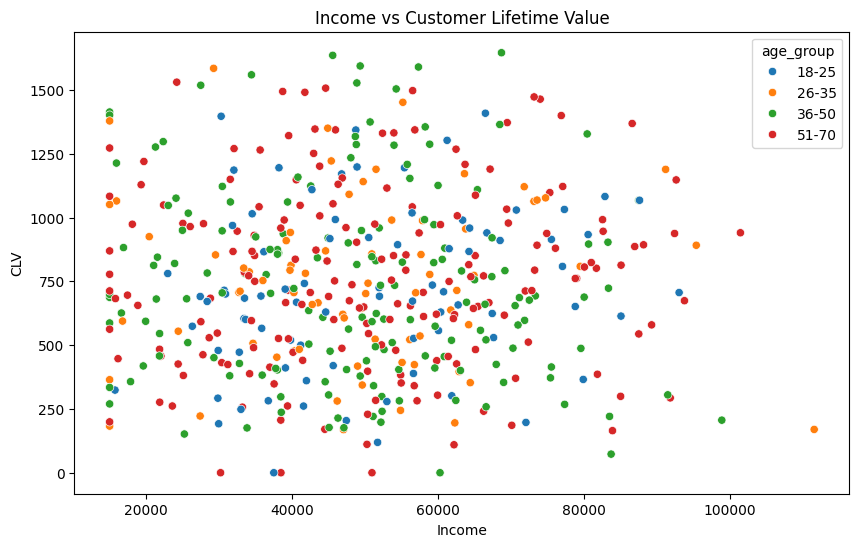

In [ ]:
#Task 5
#Income vs CLV
#Scatter plot of income vs CLV (color by age group)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Income')
plt.ylabel('CLV')

plt.show()

/tmp/ipykernel_5688/402899054.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby(


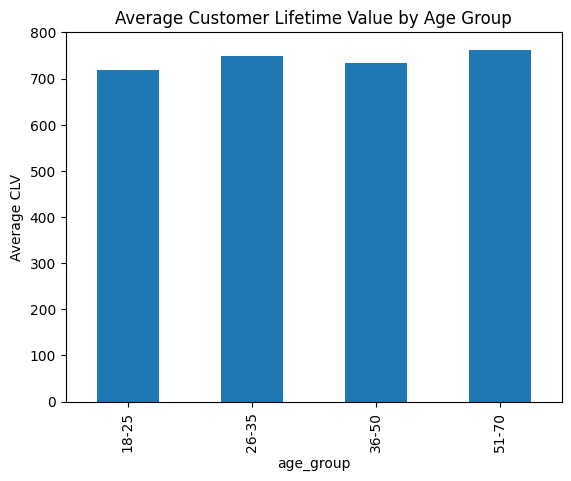

In [ ]:
#Task 6
#Average CLV by Age Group

#Bar chart of average CLV by age group

avg_clv = customers.groupby(
    'age_group'
)['CLV'].mean()

avg_clv.plot(
    kind='bar'
)

plt.title(
    'Average Customer Lifetime Value by Age Group'
)

plt.ylabel('Average CLV')

plt.show()


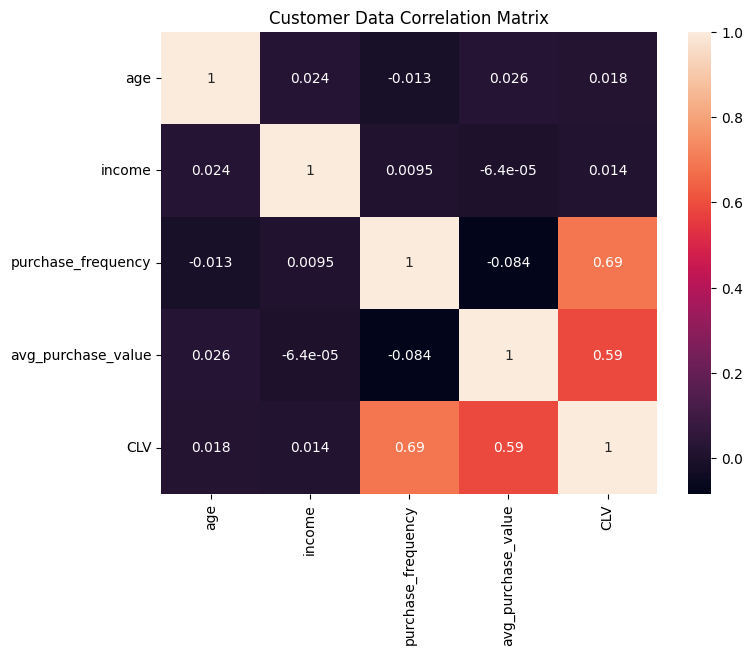

In [ ]:
#Task 7
#Correlation Heatmap
#Correlation heatmap

#Creating Correlation Matrix
correlation = customers[
    [
        'age',
        'income',
        'purchase_frequency',
        'avg_purchase_value',
        'CLV'
    ]
].corr()


#Plotting heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True
)

plt.title(
    'Customer Data Correlation Matrix'
)

plt.show()

#Analysis Paragraph

The customer dataset was analyzed to understand customer lifetime value (CLV), purchasing behavior, and the relationship between customer characteristics and business value.

From the age group analysis, the age group with the highest average CLV is 51-70. This indicates that the customers in this category contribute more value on average than the other age groups. It can be seen that the top 10% of customers by CLV all fall into the 36-50 and 51-70 age groups. This signifies that the company's most valuable costumers are middle-aged and older.There is a weak positive relationship between income and CLV indicating that income affects customer lifetime value to some extent, but it is not the main factor. From the bar chart younger groups (18-25 and 26-35) have a lower average CLV, while older groups (36-50 and 51-70) have a higher average CLV.  This implies that  older customers tend to spend more or stay longer with the business compared to younger ones.Inferring from  the heatmap that CLV has a strong correlation with purchase frequency (0.69) and average purchase value (0.59). Age and income, however, show almost no correlation with CLV (0.018 and 0.014) . This implies that how often someone buys and how much they spend per purchase really matter for clv but age and income barely matter at all.